##### ***注意力汇聚：Nadaraya-Watson核回归***
###### 上节主要介绍了注意力机制的构成，而Q和K之间的交互形成了注意力汇聚，选择一个合适的方案，来计算注意力汇聚。而1964年提出的Nadaraya-Watson核回归，是一种基于核函数的回归方法，用于解决非线性回归问题。

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
n_train = 50
x_train, _ = torch.sort(torch.rand(n_train) * 5) #生成0-5之间的随机数并排序

# 真实函数
def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))
x_test = torch.arange(0, 5, 0.1)
y_truth = f(x_test)
n_test = len(x_test)
n_test

50

In [ ]:
# 下面的函数将绘制所有的训练样本（样本由圆圈表示）， 不带噪声项的真实数据生成函数f（标记为“Truth”）， 以及学习得到的预测函数（标记为“Pred”）。
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'],
             xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);

###### 基于平均汇聚来计算所有训练样本输出值的平均值：$$f(x) = \frac{1}{n}\sum_{i=1}^ny_i$$

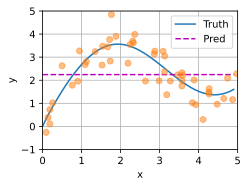

In [ ]:
# 先用最简单的平均汇聚来解决回归问题
y_hat = torch.repeat_interleave(y_train.mean(), n_test) # 用于重复张量元素
plot_kernel_reg(y_hat)

##### ***非参数注意力汇聚***
###### 显然，平均汇聚忽略了输入$x_i$，于是Nadaraya和Watson提出了更好的方法：根据输入与输出的距离对$y_i$进行加权：$$f(x) = \sum_{i=1}^n\frac{K(x-x_i)}{\sum_{j=1}^nK(x-x_j)}y_i$$<br>其中K是核函数，而此公式被称为Nadaraya-Watson核回归，受此启发，我们可以从注意力机制框架的角度重写成一个更通用的注意力汇聚公式：$$f(x) = \sum_{i=1}^n\alpha(x, x_i)y_i$$，式中，x是查询，$(x_i, y_i)$是键值对，注意力汇聚是$y_i$的加权平均，将查询x和键$x_i$之间的关系建模为注意力权重$\alpha(x, x_i)$，这个权重将被分配给每一个对应值$y_i$，而对于任何的查询，所有键值对的注意力权重都是一个有效的概率分布，它们非负且总和为1.利用核函数计算Q和K的相似度从而分配权重，这里我们引入高斯核：$K(u) = \frac{1}{\sqrt(2\pi)}exp(-\frac{u^2}{2})$，将其代入可得：
$$\begin{split}
f(x) 
&= \sum_{i=1}^n\alpha(x, x_i)y_i\\
&= \sum_{i=1}^n\frac{exp(-\frac{1}{2}(x-x_i)^2)}{\sum_{j=1}^nexp(-\frac{1}{2}(x-x_j)^2)}y_i\\
&= \sum_{i=1}^nsoftmax(-\frac{1}{2}(x-x_i)^2)y_i
\end{split}
$$
###### 其中，如果一个键越是接近给定的查询，那么分配给这个键对应值的注意力权重就越大，也就是说获得了更多的注意力。值得注意的是，Nadaraya-Watson核回归是一个非参数方法，因此它没有参数需要学习，只需要根据数据的相似度进行加权即可。


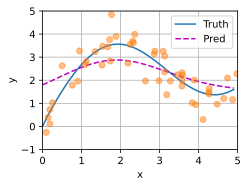

In [5]:
# X_repeat的形状是(n_test, n_train)
# 每一行都包含着相同的测试输入
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# x_train包含着键。attention_weights的形状：(n_test,n_train),
# 每一行都包含着要在给定的每个查询的值（y_train）之间分配的注意力权重
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

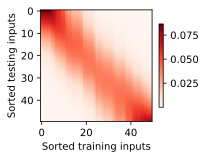

In [6]:
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')

##### ***带参数注意力汇聚***
###### 虽然非参数的注意力汇聚具有一致性的有点，也就是说如果有足够多的数据，此模型会被收敛到最优结果，然而它的弊端也很明显，就是核函数是固定的，而我们可以将其转换为可学习的参数，从而实现参数化注意力汇聚。我们可以在查询和键之间乘以一个可学习的参数$w$：
$$\begin{split}
f(x) 
&= \sum_{i=1}^n\alpha(x, x_i)y_i\\
&= \sum_{i=1}^n\frac{exp(-\frac{1}{2}((x-x_i)w)^2)}{\sum_{j=1}^nexp(-\frac{1}{2}((x-x_j)w)^2)}y_i\\
&= \sum_{i=1}^nsoftmax(-\frac{1}{2}((x-x_i)w)^2)y_i
\end{split}
$$

In [7]:
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

In [ ]:
weights = torch.ones((2, 10)) * 0.1
print(weights)
values = torch.arange(20.0).reshape((2, 10))
print(values)
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1)) # 批量矩阵乘法，unsqueeze添加维度

tensor([[0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         0.1000],
        [0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         0.1000]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.],
        [10., 11., 12., 13., 14., 15., 16., 17., 18., 19.]])


tensor([[[ 4.5000]],

        [[14.5000]]])

In [19]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        # queries和attention_weights的形状为(查询个数，“键－值”对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1)
        # values的形状为(查询个数，“键－值”对个数)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)

In [ ]:
# X_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))
# Y_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))

# keys的形状:('n_train'，'n_train'-1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1)) # 剔除对角线，也就是说每个样本的输入向量中，不包含自己自己的输入
# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

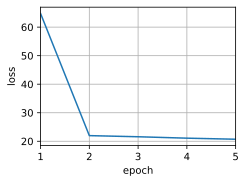

In [24]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    animator.add(epoch + 1, float(l.sum()))

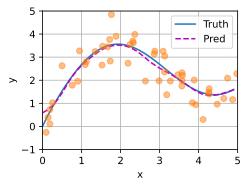

In [25]:
# keys的形状:(n_test，n_train)，每一行包含着相同的训练输入（例如，相同的键）
keys = x_train.repeat((n_test, 1))
# value的形状:(n_test，n_train)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

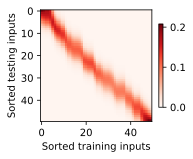

In [26]:
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')
                  